# PHT3D Example 10：只查看 MF6PQC 结果

本 notebook 只读取 `examples/PHT3D_E10/output` 中本案例生成的结果，不依赖官方 PHT3D 对照文件。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, cwd / 'examples' / 'PHT3D_E10']
candidates.extend(parent / 'examples' / 'PHT3D_E10' for parent in cwd.parents)
case_dir = next(
    (path for path in candidates if (path / 'run.py').is_file() and (path / 'input_data').is_dir()),
    None,
)

output_dir = case_dir / 'output'
results_path = output_dir / 'results.npy'
headings_path = output_dir / 'results_headings.txt'
times_path = output_dir / 'results_times.npy'
required = (results_path, headings_path, times_path)
missing_files = [str(path) for path in required if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        '缺少本案例结果文件：' + ', '.join(missing_files) +
        '；请先运行 examples/PHT3D_E10/run.py。'
    )

NROW, NCOL = 40, 80
headings = [line.strip() for line in headings_path.read_text(encoding='utf-8-sig').splitlines() if line.strip()]
results = np.load(results_path, allow_pickle=False)
times = np.load(times_path, allow_pickle=False)

field_data = {
    name: results[:, headings.index(name)].reshape(len(times), NROW, NCOL)
    for name in headings
}

# 修改这里可以查看其他时刻；默认查看最后一帧。
plot_time = float(times[-1])
frame_index = int(np.argmin(np.abs(times - plot_time)))
frame_time = float(times[frame_index])

SPATIAL_NAMES = (
    'Benzene', 'Toluene', 'Oxygen', 'Nitrate', 'Sulfate', 'Methane',
    'DIC', 'Goethite', 'Pyrite', 'Calcite', 'pH', 'Ca',
)
missing_fields = sorted(set(SPATIAL_NAMES) - set(field_data))
if missing_fields:
    raise KeyError(f'结果中缺少绘图字段：{missing_fields}')

NAPL_NAMES = tuple(name for name in ('Benznapl', 'Tolunapl', 'Ethynapl', 'Xylnapl') if name in field_data)
print(f'案例目录：{case_dir}')
print(f'结果形状：{results.shape}；时间范围：{times[0]:g}–{times[-1]:g} d')
print(f'当前绘图时刻：{frame_time:g} d')

案例目录：D:\Archives\Python\mf6pqc\examples\PHT3D_E10
结果形状：(51, 16, 3200)；时间范围：0–500 d
当前绘图时刻：500 d


## 2. 水平分布

色标根据本案例当前时刻的数据自动设置，便于直接观察羽流和反应区。

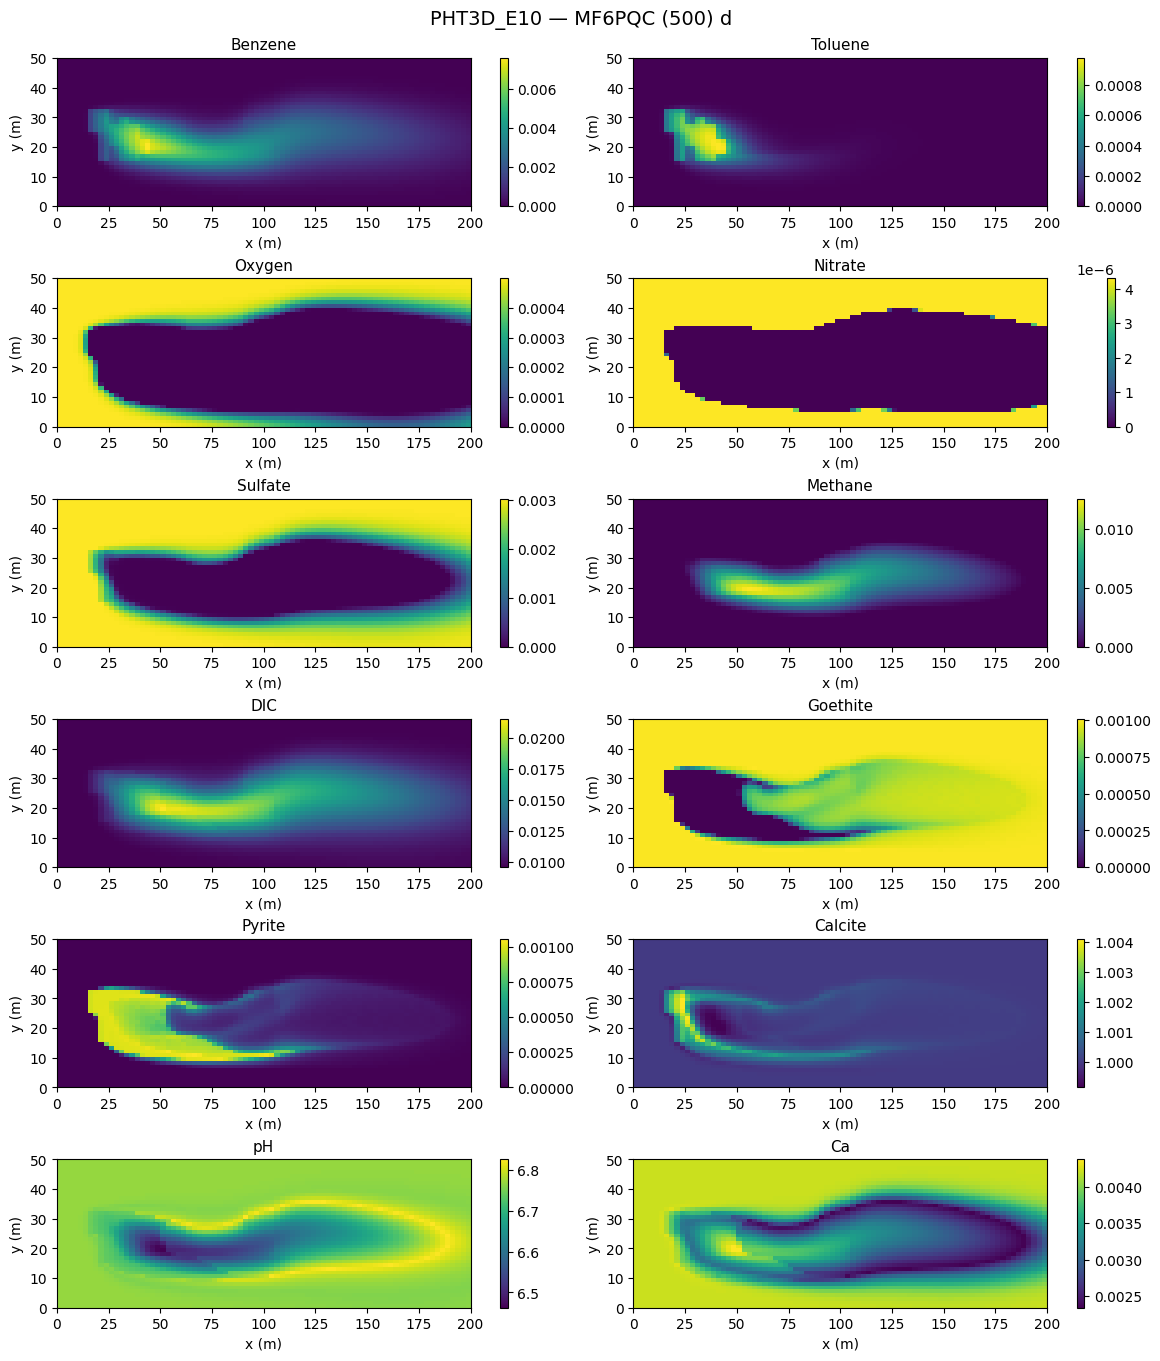

In [2]:
def color_limits(field):
    vmin = float(np.nanmin(field))
    vmax = float(np.nanmax(field))
    if np.isclose(vmin, vmax):
        delta = max(abs(vmax) * 0.01, 1.0e-12)
        vmin -= delta
        vmax += delta
    return vmin, vmax

ncols = 2
nrows = (len(SPATIAL_NAMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(11.5, 13.5), constrained_layout=True)
axes = np.asarray(axes).ravel()
extent = (0.0, 200.0, 0.0, 50.0)

for ax, name in zip(axes, SPATIAL_NAMES):
    field = field_data[name][frame_index]
    vmin, vmax = color_limits(field)
    image = ax.imshow(
        field[::-1], origin='lower', extent=extent, aspect='auto',
        cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest',
    )
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    fig.colorbar(image, ax=ax, fraction=0.05, pad=0.04)

for ax in axes[len(SPATIAL_NAMES):]:
    ax.set_visible(False)

fig.suptitle(f'PHT3D_E10 — MF6PQC ({frame_time:g}) d', fontsize=14)
plt.show()